# Bead on a Rotating Hoop


## *Imports*


In [1]:
import numpy as np

from solution_bead import solution
from plotting_bead import plot_sol, plot_energy, phase_plane_comparison, plot_dimensionless_potential, plot_dimensionless_energy, plot_bifurcation


## **Solving**


In this project the topic of a bead with mass $m$, rotating on the surface of a sphere with radius $R$ with angular velocity $\Omega$. Each spherical angle $\theta (t), \phi (t)$ are time dependent, and $\theta$ is measured from the 'bottom' (i.e $\theta = 0$ means the mass is at the bottom of the hoop), opposite to convention. Due to the angular velocity, we have $ \phi (t) = \Omega t$, hence the position vector of the mass is given by:
$$

x(t) = R \sin{\theta(t)} \cos {\Omega t}

$$

$$

y(t) =  R \sin {\theta (t)} \sin {\Omega t}

$$
$$

z(t) = - R \cos {\theta (t)}

$$

The equations of motion can be calculated using the Lagrangian and the Euler-Lagrange equations. The Lagrangian here is given by:
$$
L = T - V
$$
where $T$ is the kinetic energy of the system, and $V$ is the potential energy of the system. The Euler-Lagrange equations are derived by using the principle of least action, and are given by:
$$
\frac{\partial L}{\partial \theta} = \frac{d}{dt} \frac{\partial L}{\partial \dot \theta}
$$
where we have only given the equations in terms of $\theta$ as that is our only variable here.

The kinetic energy $T = \frac{1}{2} m v^2$ requires the squared speed, given by $v(t)^2 = \dot x(t) ^2 + \dot y(t) ^2 + \dot z(t) ^ 2$. Differentiating the position vector gives:
$$
\dot x(t) = R \left( \dot {\theta} (t) \cos {\theta (t)} \cos {\Omega t} - \Omega \sin {\theta (t)} \sin {\Omega t} \right )
$$
$$
\dot y(t) = R \left( \dot {\theta} (t) \cos {\theta (t)} \sin {\Omega t} + \Omega \sin {\theta (t)} \cos {\Omega t} \right )
$$
$$
\dot z(t) = R \dot {\theta}(t) \sin {\theta (t)}
$$


Then, we have:

$$ 
v(t)^2 = R^2 \left( \left( \dot {\theta} (t) \cos {\theta (t)} \cos {\Omega t} - \Omega \sin {\theta (t)} \sin {\Omega t} \right )^2 + \left( \dot {\theta} (t) \cos {\theta (t)} \sin{\Omega t} + \Omega \sin {\theta (t)} \cos {\Omega t} \right )^2 + \dot {\theta} (t) ^2 \sin ^2 {\theta} (t) \right) 
$$

$$
= R^2 \left(\dot \theta(t) ^2 \cos ^2 \theta(t) + \Omega ^2 \sin ^2 \theta(t)  + \dot \theta(t) ^2 \sin^2\theta(t) \right) 
$$

$$
= R^2 \left(\dot \theta(t) ^2 + \Omega ^2 \sin^2\theta(t)\right)
$$

And hence:
$$
T = \frac{1}{2} m v^2 = \frac{1}{2} m R^2 \dot {\theta}(t)^2 + \frac{1}{2} m R^2 \Omega^2 \sin^2 {\theta(t)}
$$
The potential energy is given by:
$$
V = m g z = - m g R \cos {\theta(t)}
$$
And hence the Lagrangian is given:
$$
L = \frac{1}{2} m R^2 \dot {\theta}(t)^2 + \frac{1}{2} m R^2 \Omega^2 \sin^2 {\theta(t)} + m g R \cos {\theta(t)}
$$


From the Euler-Lagrange equations, we get:

$$
\frac{d}{dt}\left( m R^2 \dot {\theta}(t) \right) = m R^2 \Omega ^2 \cos {\theta(t)} \sin {\theta(t)} - m g R \sin {\theta(t)}
$$
$$
\implies \ddot{\theta}(t) = \sin {\theta(t)} \left( \Omega ^2 \cos{\theta}(t) - \frac{g}{R}\right)
$$ 

We approximate this solution using SciPy's `solve_ivp`.

In [2]:
t = np.linspace(0, 40, 500)
R = 2.0
g = 9.81
Omega = 4.0
y0=[0, 0.2] #in format [theta(0), theta_dot(0)]

sol = solution(R=R, g=g, Omega=Omega, y0=y0,t=t)

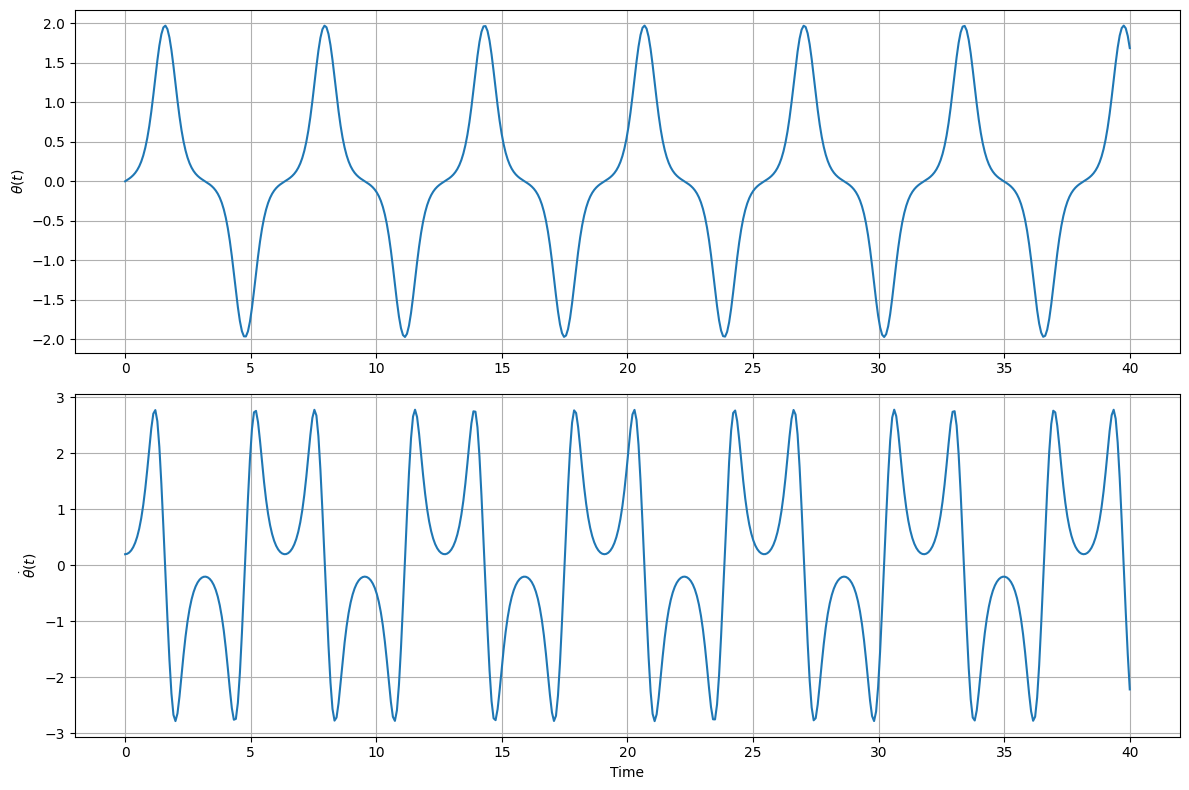

In [3]:
_ = plot_sol(sol)

The above plot gives the time evolution of $\theta, \dot{\theta}$ for the solution to the rotating hoop. See both distributions are $2 \pi$ periodic, and that maximum amplitudes do not decrease. This is due to our assumption of no damping/friction, if damping was included, then we would expect decreasing maximum amplitudes as time increases.

## **Effective Energy**


Now investigate the energy of the system. Notice that our lagrangian does not depend on time, hence the effective energy of the system is given by:
$$
\epsilon = \dot{\theta} \frac{\delta L}{\delta \dot{\theta}} - L
$$
$$
= \frac{1}{2} m R^2 \dot{\theta}^2 - \frac{1}{2} m R^2 \Omega ^2 \sin^2{\theta} - m g R \cos{\theta}
$$

This is plotted below, and we expect it to be constant in time, since:
$$
\frac{d \epsilon}{dt} = m R ^2 \dot{\theta} \ddot{\theta} - m R^2 \Omega ^2 \dot{\theta} \sin{\theta} \cos{\theta} + m g R  \dot{\theta} \sin{\theta} 
$$
$$
= m R^2 \dot{\theta} \underbrace{\left( \ddot{\theta} - \Omega^2 \sin{\theta} \cos{\theta} + \frac{g}{R} \sin{\theta}\right)}_{= 0}
$$
since that is the solution for $ \ddot{\theta} $ as seen above. Hence we expect $\epsilon(t) = \epsilon(0)$

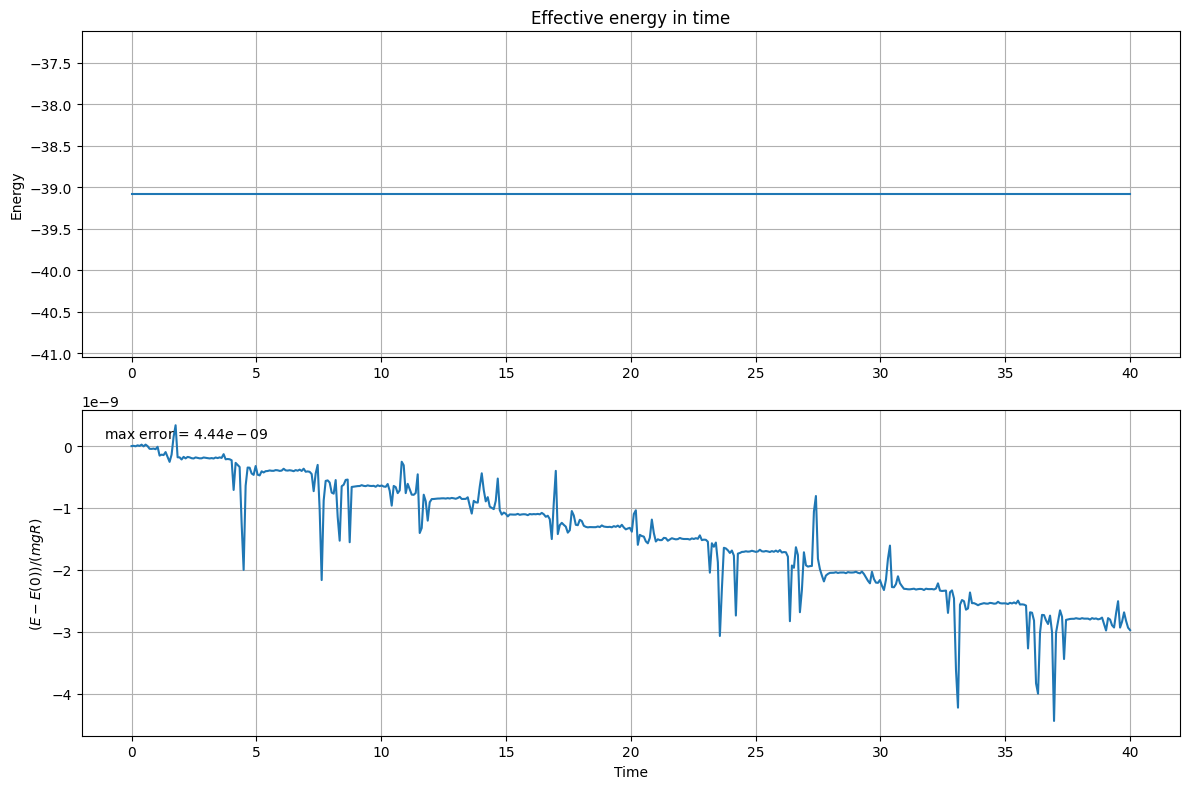

In [4]:
m = 2.0 #2kg point mass on hoop

_ = plot_energy(sol=sol, m=m, R=R, g=g, Omega=Omega)

As expected, we see that the effective energy is effectively constant in time, with small deviations being due to the numerical approximation of our solution. There is a factor of $mgR$ there which I shall explain the origin of. Errors are best used when they are non-dimensional, and notice E(t) - E(0) has dimensions of energy. $mgR$ has the same dimensions as a gravitational potential energy, and hence an energy, so $\frac{E(t) - E(0)}{mgR}$ is the dimensionless quantity plotted on the bottom panel. See it varies (in absolute value) between $10^{-9}, 4*10^{-9}$, so error is very small, which is expected as this is meant to be a constant.

## **Equilibrium Points**


We now discuss equilibrium points and their stability. Let $f: S^{1} \to \mathbb{R}$, $ f(\theta) = \ddot{\theta}$ (continuity of the derivative of $\ddot{\theta}$ required for the problem to be well-posed, and valid stability analysis). Hence, have:
$$
f(\theta) = \sin{\theta} \left(\Omega ^2 \cos{\theta} - \frac{g}{R}\right)
$$

At equilibrium points, have $\dot{\theta} = \ddot{\theta} = 0 \implies f(\theta) = 0$, hence:
$$
\sin{\theta} \left(\Omega ^2 \cos{\theta} - \frac{g}{R}\right) = 0
$$
Giving solutions $\theta = 0, \pi$ and $\theta = \pm \cos^{-1}(\frac{g}{R \Omega^2})$, since $\theta \in [0, 2\pi)$. Let $\theta_{e} = \cos^{-1}(\frac{g}{R \Omega^2})$ (positive equilibrium point). The argument of inverse cosine must have absolute value less than 1, else no solution exists, and since $g, R, \Omega^2 > 0$, for this equilibrium point to exist, it must satisfy:
$$
\frac{g}{R \Omega^2} \leq 1 \implies \Omega \geq \sqrt{\frac{g}{R}}
$$
Hence let $\Omega_{c} := \sqrt{\frac{g}{R}}$ critical angular velocity.


To discuss stability, we look at $f'(\theta)$, so differentiating we get:
$$
f'(\theta) = \cos{\theta} \left(\Omega^2 \cos{\theta} - \frac{g}{R}\right) - \Omega^2 \sin^{2}{\theta}
$$
giving:
$$
f'(0) = \Omega ^2 - \frac{g}{R}, f'(\pi) = - \left(-\Omega^2 - \frac{g}{R} \right) = \Omega^2 + \frac{g}{R}, f'(\theta_{e}) = - \Omega ^ 2 \sin^2{\theta_{e}}
$$

Now consider each individual case.

$\theta = 0$:

For $\Omega < \sqrt{\frac{g}{R}} = \Omega_{c} \implies$ system is in stable equilibrium at $\theta = 0$, and for $\Omega > \Omega_{c}$ the system is in unstable equilibrium. Intuitively, this means that if $\Omega < \Omega_{c}$, when the mass is at the bottom of the hoop, and gets displaced slightly, it eventually returns to its equilibrium point of $\theta = 0$, equivalently the mass oscillates about $\theta=0$. When $\Omega > \Omega_{c}$ and the point mass is slightly displaced from its equilibrium position, it does not return to its equilibrium position and oscillates in the opposite way around $\theta = \pi$, but approaches $\theta = 0$ at the end points of its oscillation.

$\theta =\pi$

Notice, since $g, R, \Omega ^2 > 0 \implies f'(\pi) > 0$, so unstable equilibrium point at $\theta = \pi$ for any value of $\Omega \in \mathbb{R}$ chosen. This makes intuitive sense, as at $\theta = \pi$, the mass is at the top of the hoop, hence after slight displacement from the very top, we would expect the mass to not oscillate about $\theta = \pi$, but oscillate in the opposite direction, oscillating around $\theta = 0$ but with much larger displacements.

Assume $\Omega > \Omega_{c}$, then $\theta_{e}$ exists, so assume $\theta = \pm \theta_{e}$:

$\Omega ^2, \sin^2 {\theta} > 0 \implies f'(\theta_{e}) < 0$, so at this point we always have stable equilibrium. Intuitively, that is for $\theta$ displaced slightly from $\theta_{e}$, we expect the mass to oscillate around $\theta_{e}$. This is strange to think about, as how can there be a specific angle theta for which we have equilibrium, and moreover that it is stable? It is also dependent on the fixed value of $\Omega$ chosen, and doesn't exist for certain values chosen. 

To gain some insight, we investigate certain values of $\Omega$ either side of $\Omega_{c}$. Notice briefly at $\Omega = \Omega_{c}$, $\theta_{e} = 0 \implies f'(\theta_{e}) = 0$, so stability analysis is inconclusive. Below is a phase plane comparison between different values of $\Omega$

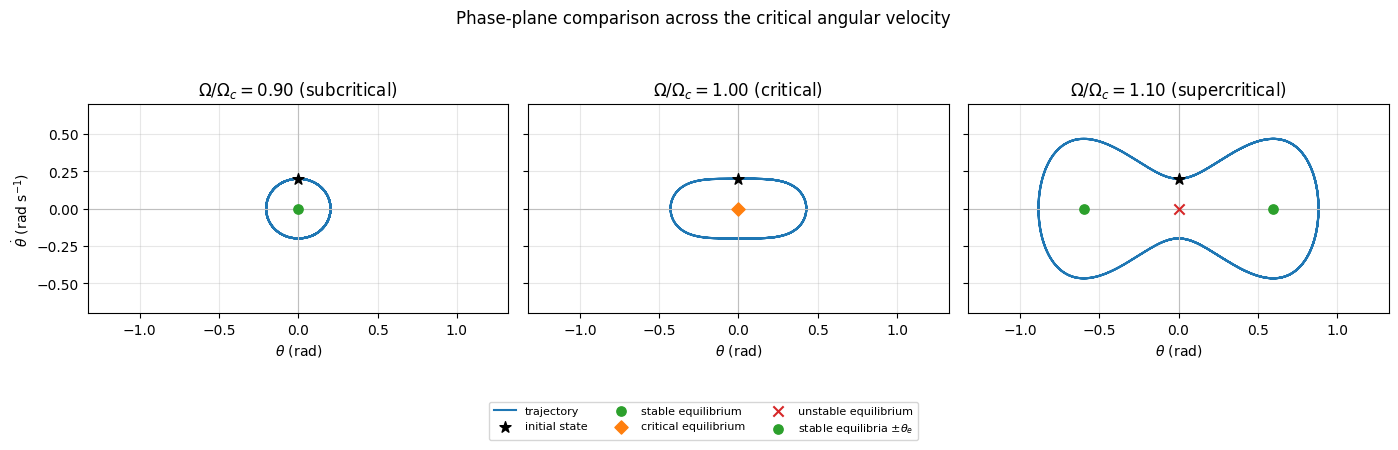

In [5]:
Omega_c = np.sqrt(g / R)
Omega_values = [0.9*Omega_c, Omega_c, 1.1 * Omega_c]

sol_1 = solution(R=R, g=g, Omega=Omega_values[0], y0=y0, t=t)
sol_2 = solution(R=R, g=g, Omega=Omega_values[1], y0=y0, t=t)
sol_3 = solution(R=R, g=g, Omega=Omega_values[2], y0=y0, t=t)

_ = phase_plane_comparison(sol_1, sol_2, sol_3, Omega_values=Omega_values, R=R, g=g)


It seems from the phase plane for $\Omega = \Omega_{c}$, $\theta_{e} = 0$ is a stable equilibrium point, but as $\Omega$ increases past this benchmark, $\theta=0$ becomes unstable, with both $\pm \theta_{e}$ being stable equilibrium points. For $\Omega < \Omega_{c}$, there is only one plotted equilibrium point $\theta=0$ which is always stable. This aligns with our stability analysis as $\theta = 0$ was expected to be stable for $\Omega < \Omega_{c}$, inconclusive (now conclude stable) at $\Omega = \Omega_{c}$, and unstable for $\Omega > \Omega_{c}$

## **Effective Potential**


Now move onto looking at the potential of this system. To make any sense of where the potential comes from, we start by considering the force on the system. There are two main forces to look at, centripetal and gravitational. We only care about each of these in the $\theta$ direction, as that is the direction of torque. Let $F_{\theta} = F \cdot \mathbf{e}_{\theta}$, where $\mathbf{e}_{\theta}$ is the unit vector in the $\theta$ direction

For gravitational:
$$
\mathbf F_g=-mg\mathbf{e}_z.
$$
Let $e_{r}$ be the radial unit vector in cylindrical co-ordinates. Then, it is a standard vector calculus result that $\mathbf{e}_{\theta} = \cos\theta\,\mathbf{e}_r + \sin\theta\ \mathbf{e_z}$. Hence the component of gravitational force in the $\theta$ direction is:
$$
F_{g,\theta} =(-mg\ \mathbf e_z)\cdot \left(\cos\theta\,\mathbf e_r + \sin\theta\,\mathbf e_z \right),
$$
$(\mathbf{e}_{\phi}, \mathbf{e}_{r}, \mathbf{e}_{z})$ form an orthonormal basis in cylindrical co-ordinates, hence $\mathbf{e}_{z}, \mathbf{e}_{r}$ orthonormal, hence:
$$
F_{g,\theta}=-mg\sin\theta.
$$

For Centripetal:

Bead's perpendicular distance from vertical rotation axis is $r = R \sin \theta$, hence the centripetal force is given by:

$$
\mathbf F_{\mathrm{c}} = m\Omega^2 R\sin\theta \mathbf {e}_r.
$$
Hence its $\theta$ component is given by:
$$
F_{\mathrm{c},\theta} = m\Omega^2R\sin\theta \mathbf{e}_r \cdot \left( \cos\theta\ \mathbf{e}_r + \sin\theta \mathbf{e}_z \right) \implies F_{\mathrm{c},\theta} = m\Omega^2 R\sin\theta\cos\theta.
$$
since $(\mathbf{e}_{\phi}, \mathbf{e}_{r}, \mathbf{e}_{z})$ form an orthonormal basis in cylindrical co-ordinates as before.





The torque of the system is given by $\tau_{\theta} = RF_{\theta}$, hence we have: 
$$
\tau_{\theta} = m\Omega^2 R^2 \sin\theta\cos\theta - mgR\sin\theta
$$

The effective potential ($U_{\mathrm{eff}}$) for an angular co-ordinate is calculated by:
$$
\tau_\theta = -\frac{dU_{\mathrm{eff}}}{d\theta}.
$$
which may look familiar to somebody familiar with fluid dynamics/electromagnetism. A form for $U_{\mathrm{eff}} (\theta)$ is therefore given by:
$$
U_{\mathrm{eff}}(\theta) = -\int\tau_\theta\,d\theta = -mR^2\Omega^2 \int\sin\theta\cos\theta\,d\theta + mgR\int\sin\theta\,d\theta
$$
which finally gives:
$$
\boxed{U_{\mathrm{eff}}(\theta) = -\frac{1}{2}mR^2\Omega^2\sin^2\theta -mgR\cos\theta+C }
$$

where $C \in \mathbb{R}$. Recall potentials are only defined/unique up to constant, but due to the relationship this quantity holds with the lagrangian (will be seen in due course), choose $C=0$.



Then we can write:
$$
U_{\mathrm{eff}}(\theta) - U_{\mathrm{eff}}(0) = mgR(1 - \cos \theta) - \frac{1}{2} mR^2 \Omega^2 \sin^2 \theta
$$
Dividing through by $mgR \neq 0$, and recalling $\Omega^2_{c} = \frac{g}{R}$ gives:
$$
\frac{U_{\mathrm{eff}}(\theta) - U_{\mathrm{eff}}(0)}{mgR} = (1 - \cos \theta) - \frac{1}{2} \frac{\Omega^2}{\Omega_{c}^2} \sin^2 \theta
$$
In the same vein as for the energy, define $u(\theta) = \frac{U_{\mathrm{eff}}(\theta) - U_{\mathrm{eff}}(0)}{mgR}$ as the dimensionless potential. This is plotted below for varying ratios of $\frac{\Omega}{\Omega_{c}}$

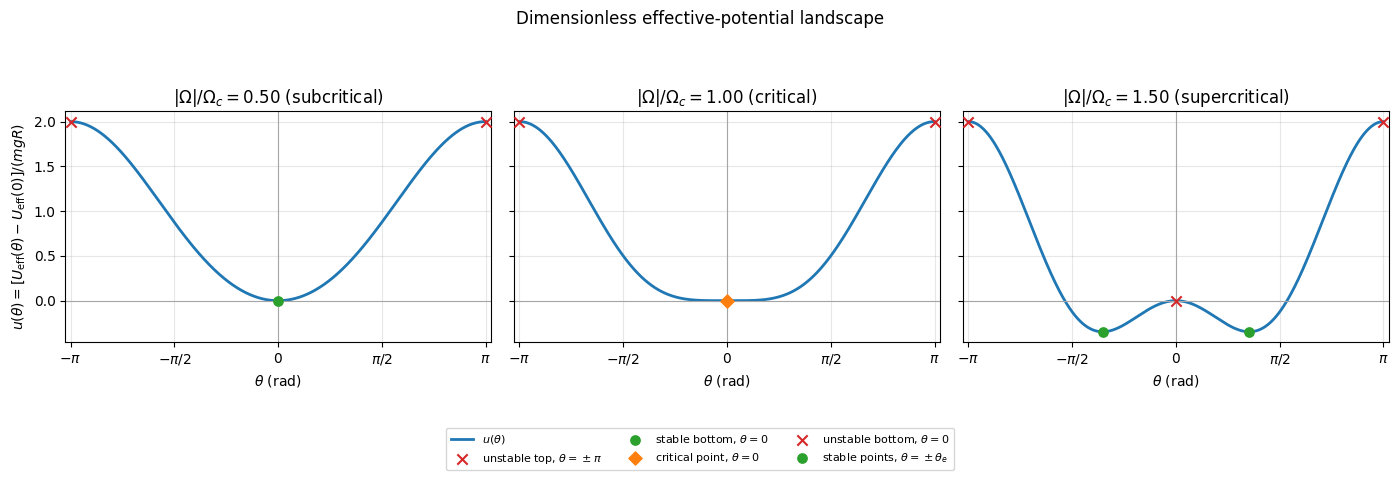

In [6]:
ratios = [0.5, 1.0, 1.5]
_ = plot_dimensionless_potential(ratios, Omega_c=Omega_c)

Now fix $\Omega > \Omega_{c}$. Recall the effective energy was given by:
$$
\epsilon = \frac{1}{2} m R^2 \dot{\theta}^2 - \frac{1}{2} m R^2 \Omega ^2 \sin^2{\theta} - m g R \cos{\theta}
$$
Let $T= \frac{1}{2} m R^2 \dot{\theta}^2$. Then the above can be rewritten as:
$$
\epsilon = T + U(\theta)
$$
Then non-dimensionalising in the same way:
$$
e(\theta) = \frac{\epsilon(\theta) - \epsilon(0)}{mgR} = \frac{T(\theta) - T(0)}{mgR} + \frac{U_{\mathrm{eff}}(\theta) - U_{\mathrm{eff}}(0)}{mgR} = \frac{\dot{\theta}^2}{2\Omega^2_{c}} + u(\theta)
$$
And hence the initial, non-dimensional energy ($\theta(t=0) = \theta_{0}$):
$$
e_0 = e(\theta_{0}) = \frac{\dot{\theta_{0}^2}}{2 \Omega^2_{c}} + u(\theta_{0})
$$
Also, notice that motion can only exist when $e(\theta) - u(\theta) \geq 0$, since $\dot{\theta}^2, \Omega^2_{c} \geq 0 $

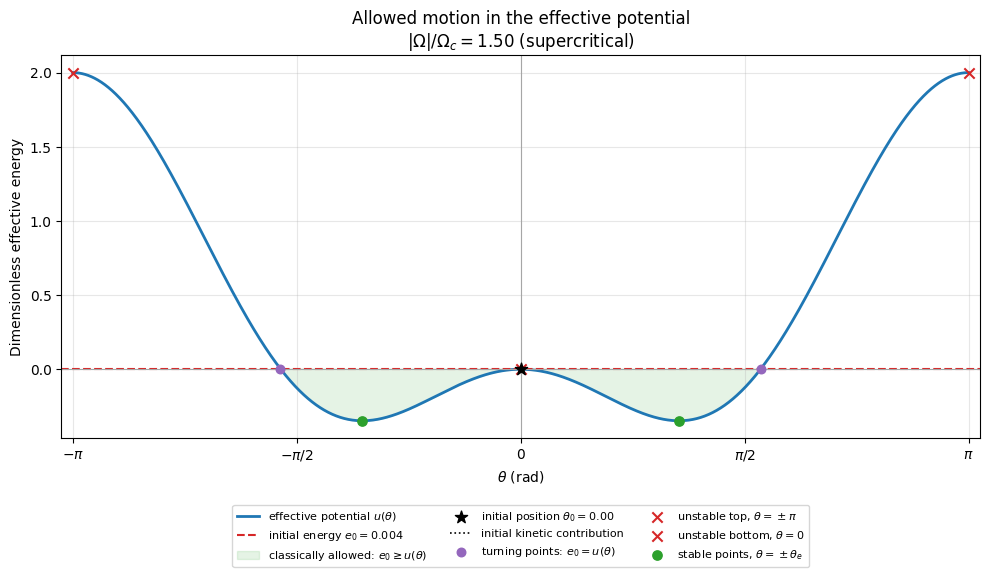

In [7]:
_ = plot_dimensionless_energy(y0=y0, Omega=1.5*Omega_c, Omega_c=Omega_c)

In the above plot, have chosen $(\theta_0, \dot{\theta_{0}})=(0, 0.2)$, so $e_0 = \frac{0.2^2}{2 \Omega_c^2} + u(0) = 0.004$ for $R=2$.

Plotted is the effective potential, along with the equilibrium points and their stability as shown above. See that each equilibrium point is a stationary point of the effective potential. Also see immediately that the motion is only classically allowed to exist when $u(\theta) \leq e(\theta)=e_0$, this doesn't hold in quantum physics as discussed in quantum_tunneling.

At a turning point, have $\dot{\theta}=0$, hence $u(\theta) = e(\theta) = e(\theta_{0}) = 0.004$ since $\epsilon$ is constant in time, as shown above. This agrees with the plot, as the turning points seen are when $u(\theta)=0.004$.  The particle feels an acceleration at these turning points back into the classically-allowed region since:
$$
\ddot{\theta} = \sin {\theta} \left(\Omega ^2 \cos{\theta} - \Omega_{c}^2\right) = -\Omega_{c}^2 u'(\theta)
$$
The only situation where this is 0 is if our turning point is also an equilibrium point, which is not the case at our turning points as seen above. Hence the particle feels an acceleration at these points, which at the $-\theta$ turning point, $u'(\theta) < 0$ so the particle is pushed towards the centre. The same thing, but the opposite way around occurs at the $+\theta$ turning point, meaning the particle is trapped classically in these regions. 

## **Bifurcation and Motion Near Equilibria**


Now look to see how our equilibrium angle $\theta_{e}$ varies as a function of $\Omega$. The plot below shows how $\theta_{e}$ varies as a function $\lambda := \frac{\Omega}{\Omega_{c}}$.

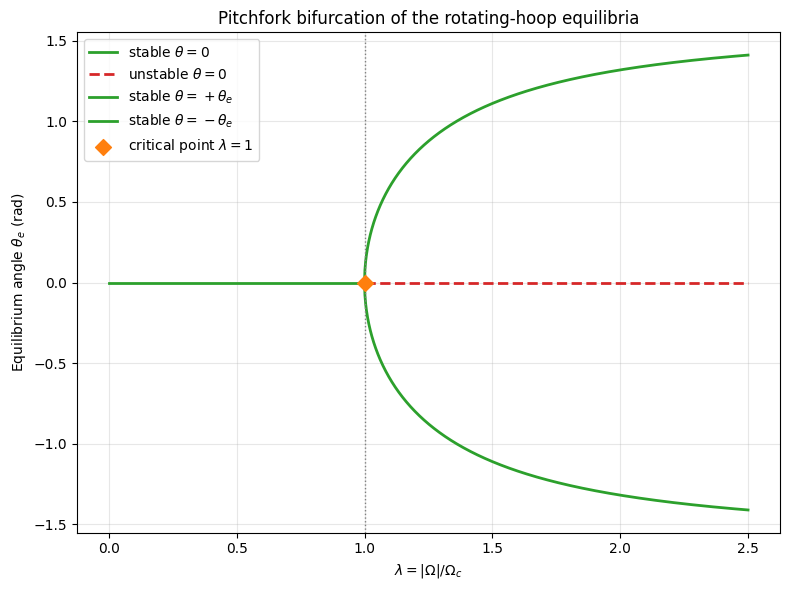

In [8]:
_ = plot_bifurcation()

For $\lambda < 1$, $\theta_{e} = 0$, and hence is a stable point as per the stability analysis done earlier. It can alternatively be thought of being stable due to it being a minimum for the potential, with a 'restoring force' towards the minimum for particles nearby, making it stable. Moreover, it is the only equilibrium point for $\lambda <1$, but loses its stability at the critical point of $\lambda=1$. At this point, $\theta_{e}$ starts to split from 0, creating a parabola around the $\theta=0$ line. The bifurcation is symmetric about this line, which can be explained by $\theta_{e}$ satisfying:
$$
\theta_{e} = \pm \cos^{-1}\left(\frac{1}{\lambda^2}\right)
$$
The instability of $\theta=0$ for $\lambda >1$ can be thought of due to it being a maximum of the effective potential, with slight deviations from this point 'falling away' from this point. The stability of $\theta_{e}$ can also be seen intuitively in the plots above, with both $\pm \theta_{e}$ being minima of the effective potential, so the same 'restoring force' argument holds. It is also important to note that $\theta=\pi$ is also an unstable equilibrium point for every $\lambda$, but is not shown on this bifurcation.

The bifurcation gives us insight on how equilibrium points vary with $\Omega$, but not the behaviour near them. This is what linearisation is. Recall at an equilibrium point $\dot{\theta} = \ddot{\theta} = 0$. Recall the $f(\theta)$ notation from before, then:
$$
 \qquad f(\theta)=\sin\theta\left(\Omega^2\cos\theta-\Omega_c^2\right),
$$
and perturb an equilibrium by setting $\theta=\theta_e+\eta$, where $|\eta|\ll1$. Since $f(\theta_e)=0$, Taylor expanding (and classing $\Theta(\eta^2)$ and above terms as negligible) we get: 
$$
\ddot{\eta}\approx f'(\theta_e)\eta,
\qquad
f'(\theta)=\cos\theta\left(\Omega^2\cos\theta-\Omega_c^2\right)-\Omega^2\sin^2\theta.
$$
If the equilibrium point is stable, we expect simple harmonic motion near that point, hence we should have the form $\ddot{\eta}+\omega^2\eta=0 \implies \omega^2=-f'(\theta_e)$ (since $\eta$ is a small angle near the equilibrium point).

For $\lambda<1$, the only stable equilibrium is $\theta_e=0$. Therefore:
$$
\ddot{\eta}+\Omega_c^2(1-\lambda^2)\eta=0,
\qquad
\boxed{\frac{\omega_-}{\Omega_c}=\sqrt{1-\lambda^2}}.
$$
For $\lambda>1$, the two stable equilibrium points satisfy $\cos\theta_e=1/\lambda^2$. For either $\pm \theta_{e}$:
$$
f'(\pm \theta_e)=-\Omega^2\sin^2\theta_e,
$$
and hence:
$$
\ddot{\eta}+\Omega^2\sin^2\theta_e\,\eta=0,
\qquad
\boxed{\frac{\omega_+}{\Omega_c}=\sqrt{\lambda^2-\lambda^{-2}}}.
$$
The system is symmetric $\theta\mapsto-\theta$, hence the frequencies are also symmetrical in this way. We are assuming no damping, hence the particle stays in equilibrium, and doesn't 'converge' to the equilibrium point.

As $\lambda\to1$ $\left(\Omega \to \Omega_{c}\right)$, both $\omega_{+}, \omega_{-} \to 0$, so $T=2\pi/\omega$ becomes large. This is called critical slowing down. At exactly $\lambda=1$ the linear term vanishes $\left(\Omega=\Omega_{c}, \theta_{e}=0 \text{ in equation for } f'(\theta_{e})\right)$, which is the reason the potential becomes increasingly flat near $\theta=0$ for the $\Omega=\Omega_{c}$ plot above. 

## **3D Render**


End with no mathematics, but a 3D render of what the system looks like physically. This has been largely overlooked in this project for applied mathematical analysis, but it is cool to end with a visual of what we were studying this whole time. The render output may not be visible when viewed on GitHub, so a GIF of the motion is attached. 

In [ ]:
from render import animate_solution
from IPython.display import HTML
import matplotlib.pyplot as plt

fig, animation = animate_solution(sol, R, Omega, frame_step=2)

plt.close(fig)
HTML(animation.to_jshtml())

![3D animation of a bead on a rotating hoop](media/bead_on_rotating_hoop.gif)

In the media file attached there is also an .mp4 of the motion, which is higher quality than the above GIF.